In [1]:
# %% [markdown]
# # lab4: GHZ 상태와 CHSH 벨 부등식
# ### 양자 머신러닝 실습 (PennyLane · Colab)
#
# lab3의 2큐빗 얽힘을 두 방향으로 확장한다.
# - **GHZ (3큐빗)**: 얽힘이 세 큐빗으로 확장 — (|000⟩+|111⟩)/√2
# - **CHSH 벨 부등식**: 얽힘이 고전을 이긴다는 *정량적* 증명 (S > 2)
#
# **학습 목표**
# 1. H + CNOT + CNOT 로 GHZ 상태를 만들고 000·111 상관을 본다.
# 2. GHZ 도 한 큐빗만 보면 무작위 — 정보는 전체 상관에 있다.
# 3. CHSH 상관값 E(a,b) 를 측정 각도별로 잰다.
# 4. S = E(a,b) − E(a,b') + E(a',b) + E(a',b') 를 계산한다.
# 5. 고전(국소숨은변수)은 |S| ≤ 2, 양자는 최대 2√2 ≈ 2.83 임을 확인한다.
#
# (그림 라벨은 영어, 코드 주석/출력은 한글)

# %%
# 설치 — Colab에서 최초 1회만: 아래 줄의 주석을 해제해 실행
!pip install -q pennylane


In [2]:

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SEED = 1234



lab4-1: GHZ 상태 — H + CNOT + CNOT

[GHZ 회로]
0: ──H─╭●────┤  Counts
1: ────╰X─╭●─┤  Counts
2: ───────╰X─┤  Counts


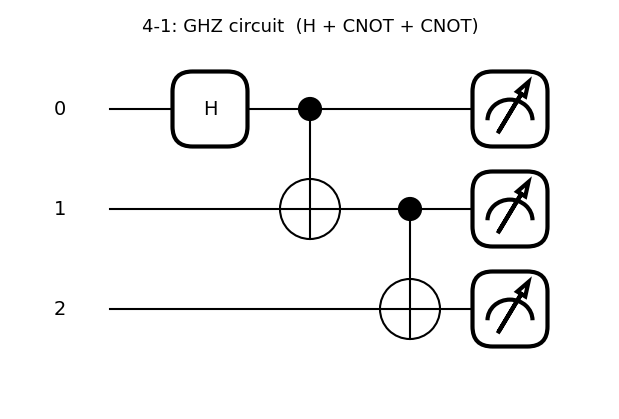

In [4]:

# %%
# ===========================================================
#  4-1: GHZ 상태 (3큐빗 얽힘)
# ===========================================================
print("=" * 60)
print("lab4-1: GHZ 상태 — H + CNOT + CNOT")
print("=" * 60)

dev3 = qml.device("default.qubit", wires=3, seed=SEED)


@qml.qnode(dev3)
def ghz_counts():
    qml.Hadamard(0)        # 큐빗0 중첩
    qml.CNOT([0, 1])       # 0 -> 1 로 상관 전파
    qml.CNOT([1, 2])       # 1 -> 2 로 상관 전파  => (|000>+|111>)/sqrt2
    return qml.counts()


print("\n[GHZ 회로]")
print(qml.draw(ghz_counts)())
fig, ax = qml.draw_mpl(ghz_counts, style="black_white")()
fig.suptitle("4-1: GHZ circuit  (H + CNOT + CNOT)", fontsize=13)
plt.tight_layout()
plt.show()



측정 확률: {'000': np.float64(0.492), '111': np.float64(0.508)}
=> 000 과 111 만 나온다. 세 큐빗이 '전부 0' 또는 '전부 1' 로 완벽히 상관.


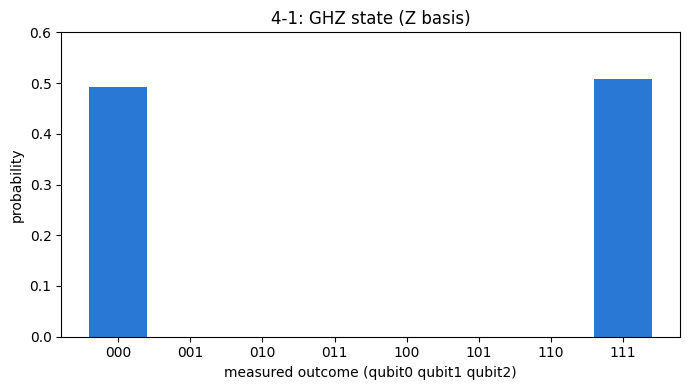

In [5]:

shots = 4000
counts = qml.set_shots(ghz_counts, shots=shots)()
labels3 = [f"{i:03b}" for i in range(8)]
probs3 = [counts.get(b, 0) / shots for b in labels3]
print("\n측정 확률:", {b: round(p, 3) for b, p in zip(labels3, probs3) if p > 0})
print("=> 000 과 111 만 나온다. 세 큐빗이 '전부 0' 또는 '전부 1' 로 완벽히 상관.")

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2a78d6" if b in ("000", "111") else "#c3c2b7" for b in labels3]
ax.bar(labels3, probs3, color=colors)
ax.set_ylim(0, 0.6)
ax.set_xlabel("measured outcome (qubit0 qubit1 qubit2)")
ax.set_ylabel("probability")
ax.set_title("4-1: GHZ state (Z basis)")
plt.tight_layout()
plt.show()



In [6]:

# %%
# ===========================================================
#  4-2: GHZ 도 한 큐빗만 보면 무작위
# ===========================================================
print("\n" + "=" * 60)
print("lab4-2: 큐빗 하나만 측정하면?")
print("=" * 60)


@qml.qnode(dev3)
def ghz_qubit0():
    qml.Hadamard(0); qml.CNOT([0, 1]); qml.CNOT([1, 2])
    return qml.probs(wires=0)


p0 = ghz_qubit0()
print(f"\n큐빗0 단독:  P(0)={float(p0[0]):.3f},  P(1)={float(p0[1]):.3f}")
print("=> 50:50 무작위. lab3의 벨과 마찬가지로 정보는 '전체 상관'에만 있다.")
print("   단, 하나가 0으로 측정되면 나머지 둘도 즉시 0으로 확정된다 (all-or-nothing).")




lab4-2: 큐빗 하나만 측정하면?

큐빗0 단독:  P(0)=0.500,  P(1)=0.500
=> 50:50 무작위. lab3의 벨과 마찬가지로 정보는 '전체 상관'에만 있다.
   단, 하나가 0으로 측정되면 나머지 둘도 즉시 0으로 확정된다 (all-or-nothing).


In [7]:

# %%
# ===========================================================
#  4-3: CHSH 상관값 E(a,b) 측정
# ===========================================================
print("\n" + "=" * 60)
print("lab4-3: CHSH — 측정 각도별 상관값")
print("=" * 60)

dev2 = qml.device("default.qubit", wires=2, seed=SEED)


# 큐빗을 각도 theta 로 측정 = 관측량 A(theta)=cos(theta)Z + sin(theta)X.
# 이를 재려면 RY(-theta) 로 측정축을 Z 로 회전시킨 뒤 Z 측정.
def E(a, b, shots=8000):
    """벨 상태에서 Alice=각도 a, Bob=각도 b 로 측정한 상관값 (같음 - 다름)."""
    @qml.qnode(dev2)
    def circ():
        qml.Hadamard(0); qml.CNOT([0, 1])     # 벨 상태 Phi+
        qml.RY(-a, 0)                          # Alice 측정축 회전
        qml.RY(-b, 1)                          # Bob   측정축 회전
        return qml.counts()
    c = qml.set_shots(circ, shots=shots)()
    tot = sum(c.values())
    same = c.get("00", 0) + c.get("11", 0)
    diff = c.get("01", 0) + c.get("10", 0)
    return (same - diff) / tot


# CHSH 최적 각도: a=0, a'=90°, b=45°, b'=135°
a, ap = 0.0, np.pi / 2
b, bp = np.pi / 4, 3 * np.pi / 4

Eab, Eabp = E(a, b), E(a, bp)
Eapb, Eapbp = E(ap, b), E(ap, bp)
print(f"\nE(a , b ) = {Eab:+.3f}   (a=0°,  b=45°)")
print(f"E(a , b') = {Eabp:+.3f}   (a=0°,  b'=135°)")
print(f"E(a', b ) = {Eapb:+.3f}   (a'=90°, b=45°)")
print(f"E(a', b') = {Eapbp:+.3f}   (a'=90°, b'=135°)")
print("=> 각 상관값은 대략 ±cos(각도차) = ±0.707.")




lab4-3: CHSH — 측정 각도별 상관값

E(a , b ) = +0.709   (a=0°,  b=45°)
E(a , b') = -0.696   (a=0°,  b'=135°)
E(a', b ) = +0.701   (a'=90°, b=45°)
E(a', b') = +0.707   (a'=90°, b'=135°)
=> 각 상관값은 대략 ±cos(각도차) = ±0.707.



lab4-4: S 값과 벨 부등식

S = E(a,b) - E(a,b') + E(a',b) + E(a',b') = 2.813
고전(국소숨은변수) 한계 : |S| <= 2
양자 최대 (Tsirelson)   : 2*sqrt(2) = 2.828
=> S = 2.81 > 2 : 벨 부등식 위반! 얽힘은 고전으로 설명 불가.


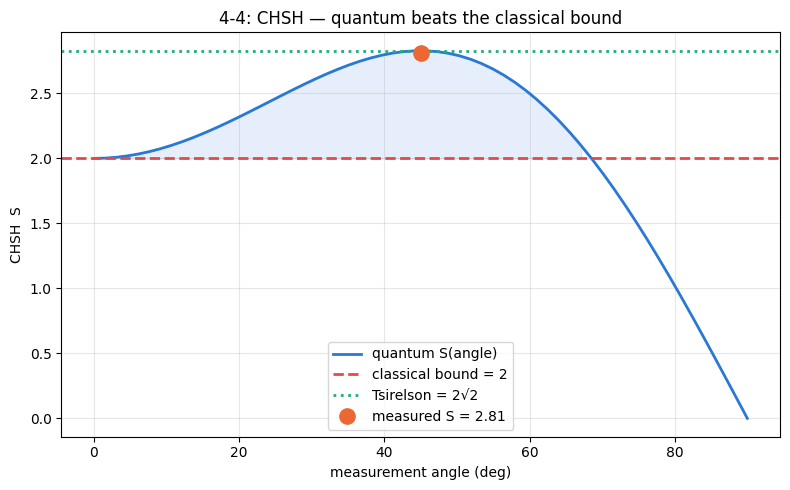

In [8]:

# %%
# ===========================================================
#  4-4: CHSH S 값 — 고전을 이긴다
# ===========================================================
print("\n" + "=" * 60)
print("lab4-4: S 값과 벨 부등식")
print("=" * 60)

S = Eab - Eabp + Eapb + Eapbp
print(f"\nS = E(a,b) - E(a,b') + E(a',b) + E(a',b') = {S:.3f}")
print(f"고전(국소숨은변수) 한계 : |S| <= 2")
print(f"양자 최대 (Tsirelson)   : 2*sqrt(2) = {2*np.sqrt(2):.3f}")
if abs(S) > 2:
    print(f"=> S = {S:.2f} > 2 : 벨 부등식 위반! 얽힘은 고전으로 설명 불가.")

# 측정 각도를 훑으며 S 가 2 를 넘는 구간을 그린다 (해석적 곡선).
def E_exact(x, y):
    @qml.qnode(qml.device("default.qubit", wires=2))
    def circ():
        qml.Hadamard(0); qml.CNOT([0, 1])
        obsA = np.cos(x) * qml.PauliZ(0) + np.sin(x) * qml.PauliX(0)
        obsB = np.cos(y) * qml.PauliZ(1) + np.sin(y) * qml.PauliX(1)
        return qml.expval(obsA @ obsB)
    return float(circ())


phis = std_np.linspace(0, np.pi / 2, 60)
S_curve = [E_exact(0, t) - E_exact(0, 3 * t) + E_exact(2 * t, t) + E_exact(2 * t, 3 * t)
           for t in phis]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.degrees(phis), S_curve, "-", color="#2a78d6", lw=2, label="quantum S(angle)")
ax.axhline(2.0, color="#e34948", ls="--", lw=2, label="classical bound = 2")
ax.axhline(2 * np.sqrt(2), color="#1baf7a", ls=":", lw=2,
           label="Tsirelson = 2\u221a2")
ax.plot([45], [S], "o", color="#eb6834", ms=11, label=f"measured S = {S:.2f}")
ax.fill_between(np.degrees(phis), 2.0, S_curve,
                where=[s > 2 for s in S_curve], color="#2a78d6", alpha=0.12)
ax.set_xlabel("measurement angle (deg)")
ax.set_ylabel("CHSH  S")
ax.set_title("4-4: CHSH — quantum beats the classical bound")
ax.legend(loc="lower center")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:

# %% [markdown]
# ## 정리
# - **GHZ**: H+CNOT+CNOT 로 세 큐빗이 000·111 로 완벽히 상관 — 얽힘의 다체계 확장.
#   한 큐빗만 보면 무작위, 하나가 정해지면 나머지도 즉시 확정된다.
# - **CHSH**: 얽힌 벨 상태를 여러 각도로 측정해 S 를 계산하면 S ≈ 2√2 ≈ 2.83.
#   어떤 고전 이론(국소숨은변수)도 |S| ≤ 2 를 넘지 못한다.
#   따라서 실험적으로 S > 2 가 나오면 = 자연은 국소적이면서 실재적일 수 없다.
#
# > 주의: 여기서는 시뮬레이터라 노이즈가 없어 이상적인 2√2 에 가깝다.
# > 실제 QPU에서는 노이즈로 S 가 줄어들지만, 여전히 2 를 넘기면 얽힘의 증거가 된다.
#
# **이 시리즈의 다음 단계**
# - 실제 IBM QPU에서 CHSH 측정 (노이즈가 S를 어떻게 깎는지)
# - 얽힘을 이용한 양자 커널 / 변분 회로 (QML 본론으로 연결)